# Tarea1

In [ ]:
# Esta código fue ejecutado localmente, por lo tanto es necesario tener instalado:
# pip install gdown torch torchvision matplotlib pillow opencv-python

import gdown
import zipfile
import torch
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import cv2
from skimage.feature import hog

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [68]:
# Descargar colección de datos
id = "1SVBgPktLEYCzOdZl-guqBUT_GgUA3iFd"
output = "CorelRetrieval.zip"
gdown.download(id=id, output=output)

# Descomprimir archivo
datasetDir = "DatosTarea1"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(datasetDir)

print(f"El archivo ha sido descargado y descomprimido en la carpeta {datasetDir}.")

Downloading...
From: https://drive.google.com/uc?id=1SVBgPktLEYCzOdZl-guqBUT_GgUA3iFd
To: c:\Users\carit\Dropbox\Carolina Universidad\2024-2\Análisis de video (Tópico I)\Tarea 1\CorelRetrieval.zip
100%|██████████| 10.4M/10.4M [00:00<00:00, 41.8MB/s]


El archivo ha sido descargado y descomprimido en la carpeta DatosTarea1.


In [69]:
imageDir = os.path.join(datasetDir, "CorelRetrieval")
image_set = []

# Se obtienen todas las imágenes (incluidas en subcarpetas) que cumplen con las extensiones aceptadas en la aplicación
for root, _, files in os.walk(imageDir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg')):
            image_set.append(os.path.join(root, file))

print(f"Total de imágenes encontradas: {len(image_set)}")

Total de imágenes encontradas: 825


In [70]:
# Se elige una imagen aleatoria de consulta
queryImage = random.choice(image_set)
print(f"Imagen de consulta: {queryImage}")

Imagen de consulta: DatosTarea1\CorelRetrieval\Sea\12069.jpeg


## Ejercicio 1 (ResNet)

Implementar una función de búsqueda para recuperar las 50-top imágenes más similares dada una
imagen de consulta tomada de la colección de datos proporcionada para esta tarea. Para este fin debe
emplear la red de aprendizaje profundo ResNet18 para obtener las descripciones necesarias. La
similitud entre imágenes debe ser calculada usando la distancia L2.

In [71]:
# Se carga modelo ResNet18 preentrenado
model = models.resnet18(pretrained=True)

# Se habilita el modo de evaluación
model.eval()

# Se manda el modelo al GPU si es posible, de lo contrario se usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Dispositivo que se esta usando: {device}")

Dispositivo que se esta usando: cpu


In [72]:
# Se prepara las transformaciones que se debe hacer a todas las imágenes:
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [73]:
# Se extraen las características de TODAS las imagenes
# Se guardan en un diccionario porque se asocia cada característica con su imagen para recuperar las más similares
features = {}

for img_path in image_set:
    img = Image.open(img_path).convert("RGB")  # Se abre la imagen en RGB
    img_tensor = transform(img).unsqueeze(0).to(device)  # Se transforma y se envia al dispositivo

    with torch.no_grad():
        feature = model(img_tensor)  # Se extraen características
    features[img_path] = feature.cpu().numpy().flatten()  # Se almacena característica

In [74]:
# Se extraen características de la imagen de consulta
query_resnet = Image.open(queryImage).convert("RGB")
query_tensor = transform(query_resnet).unsqueeze(0).to(device)

with torch.no_grad():
    query_feature = model(query_tensor).cpu().numpy().flatten()

In [75]:
# Se calcula distancia L2
# Se guardan en un diccionario con su ruta y distancia asociada
distances = {img_path: np.linalg.norm(query_feature - feature) for img_path, feature in features.items()}

# Se ordenan por similitud (se seleccionan 50 imágenes con las distancias más pequeñas)
sorted_images = sorted(distances.items(), key=lambda x: x[1])[:50]

In [76]:
# Se muestran los resultados
print("\nTop 50 imágenes más similares (ResNet):")
for i, (img_path, dist) in enumerate(sorted_images, start=1):
    print(f"Imagen {i}: {img_path}, Distancia: {dist}")


Top 50 imágenes más similares (ResNet):
Imagen 1: DatosTarea1\CorelRetrieval\Sea\12069.jpeg, Distancia: 0.0
Imagen 2: DatosTarea1\CorelRetrieval\Sea\12067.jpeg, Distancia: 45.56010055541992
Imagen 3: DatosTarea1\CorelRetrieval\Sea\12010.jpeg, Distancia: 51.676666259765625
Imagen 4: DatosTarea1\CorelRetrieval\Sea\12075.jpeg, Distancia: 52.11560821533203
Imagen 5: DatosTarea1\CorelRetrieval\Sea\12044.jpeg, Distancia: 52.11964797973633
Imagen 6: DatosTarea1\CorelRetrieval\Sea\12017.jpeg, Distancia: 52.16182327270508
Imagen 7: DatosTarea1\CorelRetrieval\Flowers\13073.jpeg, Distancia: 52.261531829833984
Imagen 8: DatosTarea1\CorelRetrieval\Sea\12008.jpeg, Distancia: 52.794918060302734
Imagen 9: DatosTarea1\CorelRetrieval\Sea\12042.jpeg, Distancia: 53.238067626953125
Imagen 10: DatosTarea1\CorelRetrieval\Sea\12099.jpeg, Distancia: 53.24485397338867
Imagen 11: DatosTarea1\CorelRetrieval\Sea\12016.jpeg, Distancia: 53.57154083251953
Imagen 12: DatosTarea1\CorelRetrieval\Flowers\13027.jpeg, Dis

In [77]:
# Se puede comparar una imagen de ejemplo (de las 50) con la imagen de consulta
def mostrarImagenesComparadas(imagenConsulta, imagenSeleccionada, distancia, descriptor, posicion):
    # Se cargan las imágenes
    query_image = Image.open(imagenConsulta).convert("RGB")
    selected_image = Image.open(imagenSeleccionada).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Imagen de consulta
    axes[0].imshow(query_image)
    axes[0].set_title("Imagen de consulta")
    axes[0].axis("off")

    # Imagen seleccionada
    axes[1].imshow(selected_image)
    axes[1].set_title(f"Imagen similar\n({descriptor}: IMG {posicion}, Dist: {distancia:.4f})")
    axes[1].axis("off")

    # Mostrar imágenes
    plt.tight_layout()
    plt.show()

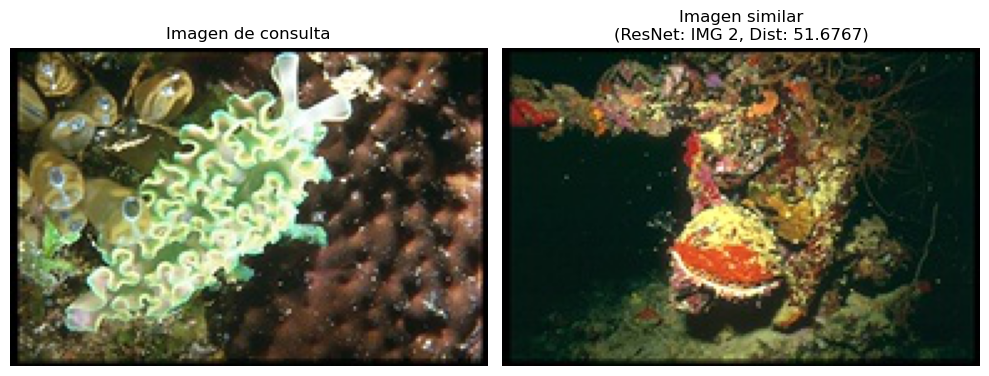

In [78]:
# Se muestra comparación de imágenes:
n = 2 # Posición elegida = Segunda imagen mas parecida (la primera es la misma imagen de consulta).
mostrarImagenesComparadas(queryImage, sorted_images[n][0], sorted_images[n][1], "ResNet", n)

## Ejercicio 2 (Presición)

Realice un experimento para computar el desempeño de la recuperación usando las imágenes de
consulta proporcionadas para esta tarea. Para medir el desempeño de la consulta calcule la Precisión
alcanzada en la recuperación (50-top) por cada tipo de descripción HOG (Histogram Oriented
Gradient), Color y ResNet-18.

### HOG Descriptor (Implementación)

In [79]:
# Se extraen las características de TODAS las imagenes
hog_features = {}

for img_path in image_set:
    image = cv2.imread(img_path, 0) # Se carga en escala de grises
    image = cv2.resize(image, (256, 256)) # Se redimensiona la imagen
    rows, cols = image.shape

    # Se calcula descriptor
    fd = hog(image, orientations=8, pixels_per_cell=(rows//16,cols//16), cells_per_block=(2,2), visualize=False)
    hog_features[img_path] = fd

In [80]:
# Se convierte los descriptores a una matriz
matrizHog = np.array(list(hog_features.values()))
print(f"Forma de la matriz de descriptores HOG: {matrizHog.shape}")

Forma de la matriz de descriptores HOG: (825, 7200)


In [81]:
# Se extraen características de la imagen de consulta
query_hog = cv2.imread(queryImage, 0)
query_hog = cv2.resize(query_hog, (256, 256))
rows, cols = query_hog.shape

# Se calcula descriptor
query_hog = hog(query_hog, orientations=8, pixels_per_cell=(rows // 16, cols // 16), cells_per_block=(2, 2), visualize=False)

In [82]:
# Se calcula las distancias L2 y ordenar por similitud
distances_hog = np.linalg.norm(matrizHog - query_hog, axis=1)
sorted_hog = np.argsort(distances_hog)[:50]

# Se muestran los resultados
print("\nTop 50 imágenes más similares (HOG):")
for i, idx in enumerate(sorted_hog, start=1):
    print(f"Imagen {i}: {list(hog_features.keys())[idx]}, Distancia: {distances_hog[idx]:.4f}")


Top 50 imágenes más similares (HOG):
Imagen 1: DatosTarea1\CorelRetrieval\Sea\12069.jpeg, Distancia: 0.0000
Imagen 2: DatosTarea1\CorelRetrieval\Flowers\13027.jpeg, Distancia: 6.5335
Imagen 3: DatosTarea1\CorelRetrieval\Flowers\13089.jpeg, Distancia: 6.6437
Imagen 4: DatosTarea1\CorelRetrieval\Flowers\13064.jpeg, Distancia: 6.7969
Imagen 5: DatosTarea1\CorelRetrieval\Flowers\13047.jpeg, Distancia: 6.8443
Imagen 6: DatosTarea1\CorelRetrieval\Flowers\13088.jpeg, Distancia: 6.9611
Imagen 7: DatosTarea1\CorelRetrieval\Sea\12040.jpeg, Distancia: 6.9702
Imagen 8: DatosTarea1\CorelRetrieval\Animals\104085.jpeg, Distancia: 7.0052
Imagen 9: DatosTarea1\CorelRetrieval\Flowers\13045.jpeg, Distancia: 7.0230
Imagen 10: DatosTarea1\CorelRetrieval\Animals\104096.jpeg, Distancia: 7.1110
Imagen 11: DatosTarea1\CorelRetrieval\Flowers\13073.jpeg, Distancia: 7.1130
Imagen 12: DatosTarea1\CorelRetrieval\Animals\41009.jpeg, Distancia: 7.1296
Imagen 13: DatosTarea1\CorelRetrieval\Flowers\13051.jpeg, Distanc

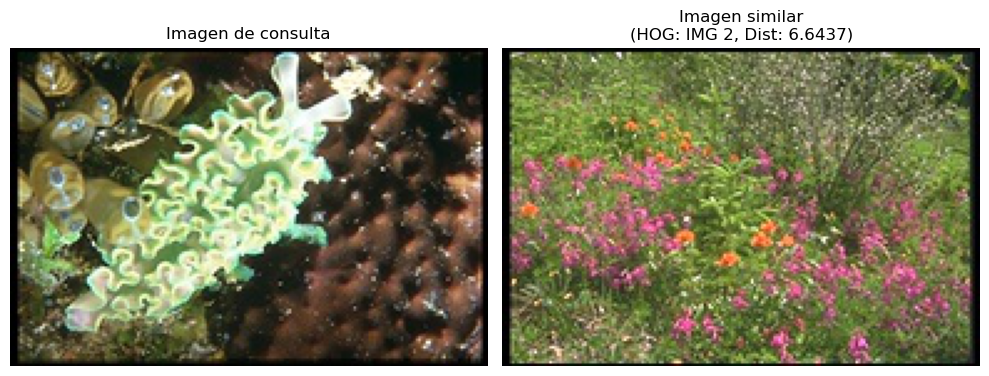

In [83]:
# Se muestra comparación de imágenes:
n = 2 # Posición elegida = Segunda imagen mas parecida (la primera es la misma imagen de consulta).
mostrarImagenesComparadas(queryImage, list(hog_features.keys())[sorted_hog[n]], distances_hog[sorted_hog[n]], "HOG", n)

### Color Descriptor (Implementación)

In [84]:
# Se extraen las características de TODAS las imagenes
color_features = {}

for img_path in image_set:
    image = cv2.imread(img_path)

    # Se convierte a HSV
    imageHSV = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Se calcula histograma
    hist = cv2.calcHist([imageHSV], [0, 1, 2], None, [4, 4, 4], [0, 180, 0, 256, 0, 256])

    # Se normaliza y aplana el histograma
    desc = hist.flatten()
    desc = desc / (image.shape[0] * image.shape[1])

    # Se almacena el descriptor
    color_features[img_path] = desc


In [85]:
# Se extraen características de la imagen de consulta
query_image_bgr = cv2.imread(queryImage)
query_image_hsv = cv2.cvtColor(query_image_bgr, cv2.COLOR_BGR2HSV)
query_hist = cv2.calcHist([query_image_hsv], [0, 1, 2], None, [4, 4, 4], [0, 180, 0, 256, 0, 256])
query_desc = query_hist.flatten() / (query_image_bgr.shape[0] * query_image_bgr.shape[1])

In [86]:
# Se calcula las distancias L2 y ordenan por similitud
distances_color = {im: np.linalg.norm(query_desc - desc) for im, desc in color_features.items()}
sorted_color = sorted(distances_color.items(), key=lambda x: x[1])[:50]

# Se muestran los resultados
print("\nTop 50 imágenes más similares (HSV):")
for i, (img_path, dist) in enumerate(sorted_color, start=1):
    print(f"Imagen {i}: {img_path}, Distancia: {dist:.4f}")


Top 50 imágenes más similares (HSV):
Imagen 1: DatosTarea1\CorelRetrieval\Sea\12069.jpeg, Distancia: 0.0000
Imagen 2: DatosTarea1\CorelRetrieval\Flowers\13046.jpeg, Distancia: 0.1323
Imagen 3: DatosTarea1\CorelRetrieval\Flowers\13071.jpeg, Distancia: 0.1367
Imagen 4: DatosTarea1\CorelRetrieval\Animals\41008.jpeg, Distancia: 0.1431
Imagen 5: DatosTarea1\CorelRetrieval\Animals\41092.jpeg, Distancia: 0.1521
Imagen 6: DatosTarea1\CorelRetrieval\Flowers\13038.jpeg, Distancia: 0.1582
Imagen 7: DatosTarea1\CorelRetrieval\Animals\41085.jpeg, Distancia: 0.1621
Imagen 8: DatosTarea1\CorelRetrieval\Sea\12099.jpeg, Distancia: 0.1704
Imagen 9: DatosTarea1\CorelRetrieval\Animals\41059.jpeg, Distancia: 0.1724
Imagen 10: DatosTarea1\CorelRetrieval\Sunset\1022.jpeg, Distancia: 0.1743
Imagen 11: DatosTarea1\CorelRetrieval\Animals\41044.jpeg, Distancia: 0.1756
Imagen 12: DatosTarea1\CorelRetrieval\Animals\41039.jpeg, Distancia: 0.1759
Imagen 13: DatosTarea1\CorelRetrieval\Animals\41081.jpeg, Distancia: 

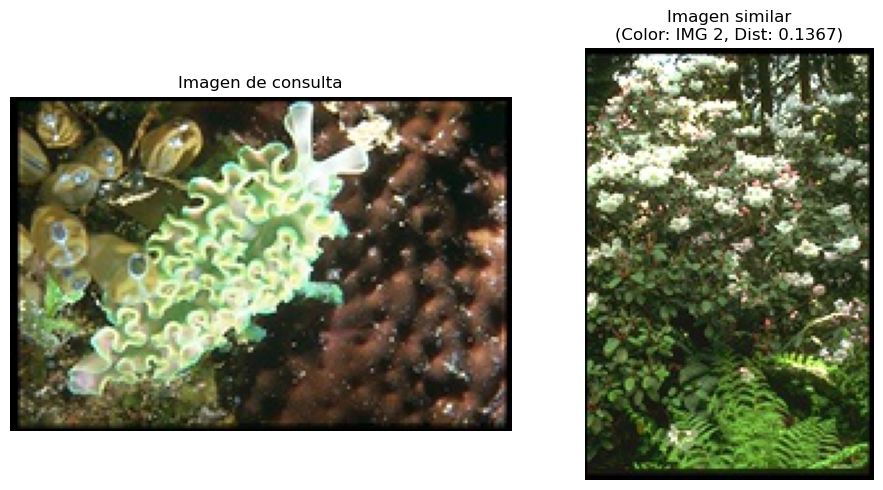

In [87]:
# Se muestra comparación de imágenes:
n = 2 # Posición elegida = Segunda imagen mas parecida (la primera es la misma imagen de consulta).
mostrarImagenesComparadas(queryImage, sorted_color[n][0], sorted_color[n][1], "Color", n)


### Medición de precisón

In [88]:
# Se crea lista de etiquetas (segun subcarpetas)
labels = [os.path.basename(os.path.dirname(img_path)) for img_path in image_set]

# Se obtiene etiqueta de la imagen de consulta
query_label = os.path.basename(os.path.dirname(queryImage))

# Se calcula el porcentaje de imágenes (de las 50) que tienen la misma etiqueta que la de consulta.
hog_precision = sum(labels[idx] == query_label for idx in sorted_hog) / 50
color_precision = sum(os.path.basename(os.path.dirname(image_path)) == query_label for image_path, _ in sorted_color) / 50
resnet_precision = sum(os.path.basename(os.path.dirname(image_path)) == query_label for image_path, _ in sorted_images) / 50

print(f"Precisión HOG: {hog_precision:.2f}")
print(f"Precisión Color (HSV): {color_precision:.2f}")
print(f"Precisión ResNet: {resnet_precision:.2f}")


Precisión HOG: 0.18
Precisión Color (HSV): 0.26
Precisión ResNet: 0.78
